# Assignment 3: Linear Models

In [19]:
import urllib.request
import os

os.makedirs('./data', exist_ok=True)

base_url = 'https://raw.githubusercontent.com/ds4e/undergrad_ml_assignments/main/data/'

files = ['Q1_clean.csv', 'cars_hw.csv', 'heart_hw.csv']

for f in files:
    urllib.request.urlretrieve(base_url + f, f'./data/{f}')
    print(f'Downloaded {f}')

Downloaded Q1_clean.csv
Downloaded cars_hw.csv
Downloaded heart_hw.csv


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1.
A model is linear when the output is just a weighted sum of the inputs. The "linear" part refers to the coefficients, not the features. So even if you square a variable and include x² it's still linear because the coefficients are just being added together, there not being multiplied or anything like that.

2.
It tells you the difference between that group and the reference group (the one that got dropped). The intercept represents the baseline, which is the predicted value for the reference category. So the dummy coefficient is basically how much higher or lower that group is compared to the baseline. Like in Q2 the bronx was dropped so the brooklyn coefficient just tells you how much more expensive brooklyn is then the bronx.

3.
Not really. The problem is it can predict values outside of 0 and 1 which doesnt make sense for a classification problem. Logistic regression is better for that since it keeps everything between 0 and 1. That said we kind of did use it that way in Q4 with the heart data and it still gave reasonable results, so its not totally useless just not ideal.

4.
The main sign is when your training error is way lower then your test error. It basically means the model is memorizing the training data instead of actually learning anything useful. You might also see really large coefficients or adding more variables keeps helping in sample but hurts on the test set.

5.
Multicolinearity is when your independent variables are correlated with eachother which makes it hard to figure out what effect each one actually has. Two stage least squares helps with this by using an instrument, which is a variable that affects your problematic predictor but doesnt directly affect the outcome. First you regress the problematic variable on the instrument to get a cleaner version of it, then you use that in your main regression. It basically removes the part of the variable thats causing the problem.

6.
You can add polynomial terms like x² or x³, or log transform your variables. You could also add interaction terms. The model is still technically linear in the parameters your just giving it more flexible features to work with so it can capture curved patterns.

7.
The slope tells you how much y is expected to change for a one unit increase in x, holding everything else constant. So if the slope is 1.02 that means a one point increase in the rating is associated with about a $1 increase in price on average.

8.
Train test split just divides the data once into two groups and you evaluate on the test set. Its simple but the results can vary a lot depending on how the data got split. K-fold is more reliable because it repeats the process k times using a different fold as the test set each time and then averages everything. It takes longer but gives a better sense of how the model actually performs.

9.
Usually people just use 5 or 10, with 10 being the most common default. Higher k gives a more accurate estimate but takes more time to run. For smaller datasets higher k makes more sense so your not training on too little data each time.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [21]:
df = pd.read_csv('./data/Q1_clean.csv')
df.columns = df.columns.str.strip()
df.rename(columns={'Review Scores Rating': 'Rating'}, inplace=True)
df.dropna(subset=['Price', 'Rating', 'Neighbourhood'], inplace=True)
df.head()

,Price,Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [22]:
summary = df.groupby('Neighbourhood')[['Price', 'Rating']].mean().round(2)
print(summary.sort_values('Price', ascending=False))
# manhattan is the most expensive by a good margin

                Price  Rating
Neighbourhood                
Manhattan      183.66   91.80
Staten Island  146.17   90.84
Brooklyn       127.75   92.36
Queens          96.86   91.55
Bronx           75.28   91.65


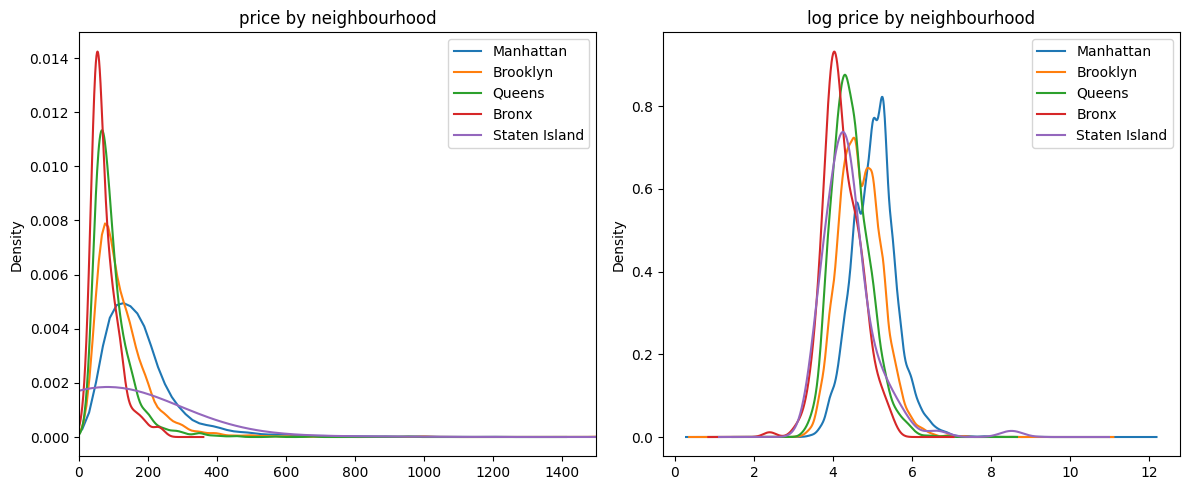

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for nb in df['Neighbourhood'].unique():
    sub = df[df['Neighbourhood'] == nb]
    sub['Price'].plot.kde(ax=axes[0], label=nb)
    np.log1p(sub['Price']).plot.kde(ax=axes[1], label=nb)

axes[0].set_xlim(0, 1500)
axes[0].set_title('price by neighbourhood')
axes[0].legend()
axes[1].set_title('log price by neighbourhood')
axes[1].legend()
plt.tight_layout()
plt.show()

In [24]:
# dropping first category so bronx is the reference, intercept = bronx mean
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True).astype(int)
X = sm.add_constant(dummies)
m2 = sm.OLS(df['Price'], X).fit()
print(m2.summary())

print(df.groupby('Neighbourhood')['Price'].mean().round(2))
# intercept matches bronx mean exactly, each coef = that borough minus bronx

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        23:48:41   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

In [25]:
X = sm.add_constant(df['Rating'])
m3 = sm.OLS(df['Price'], X).fit()
print(m3.summary())
# slope is about 1.02 - a one point increase in rating is associated with ~$1 higher price per night

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        23:48:44   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         60.8784     10.423      5.841      0.0

In [26]:
X = sm.add_constant(pd.concat([dummies, df['Rating']], axis=1))
m4 = sm.OLS(df['Price'], X).fit()
print(m4.summary())
# rating slope goes from 1.02 to 1.08, neighbourhood coefs barely change
# rating doesnt vary much across boroughs so controlling for it doesnt change much

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        23:48:46   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -23.8126     14.105     -1.688

In [27]:
df2 = df.copy()
for nb in df['Neighbourhood'].unique():
    df2[f'Rating_{nb}'] = df2['Rating'] * (df2['Neighbourhood'] == nb).astype(int)

int_cols = [c for c in df2.columns if c.startswith('Rating_')]
X = sm.add_constant(pd.concat([dummies, df2[int_cols]], axis=1))
m5 = sm.OLS(df2['Price'], X).fit()
print(m5.summary())
# manhattan and brooklyn slopes are similar (~1.3), queens and bronx are flatter and not significant
# staten island looks weird probably because theres not many observations

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:48:48   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   22.6384 

In [28]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y = df['Price'].values

def get_rmse(X):
    scores = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='neg_root_mean_squared_error')
    return -scores.mean()

print(f'model 3 (rating only):       {get_rmse(sm.add_constant(df["Rating"]).values):.2f}')
print(f'model 4 (neighbourhood+rating): {get_rmse(sm.add_constant(pd.concat([dummies, df["Rating"]], axis=1)).values):.2f}')
print(f'model 5 (separate slopes):   {get_rmse(sm.add_constant(pd.concat([dummies, df2[int_cols]], axis=1)).values):.2f}')
# model 4 has the best rmse, model 5 adds complexity but doesnt generalize better

model 3 (rating only):       144.17
model 4 (neighbourhood+rating): 140.52
model 5 (separate slopes):   141.57


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


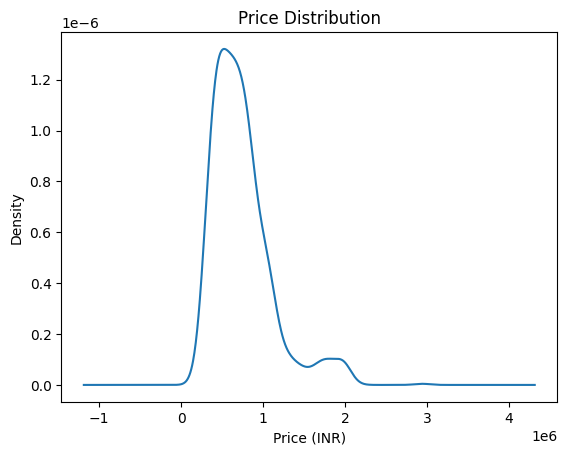

In [29]:
df3 = pd.read_csv('./data/cars_hw.csv')
print(df3['Price'].describe())
df3['Price'].plot.kde()
plt.title('Price Distribution')
plt.xlabel('Price (INR)')
plt.show()

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


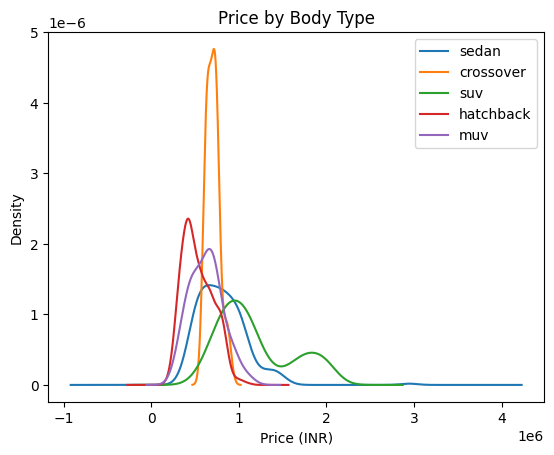

In [30]:
print(df3.groupby('Body_Type')['Price'].describe())

for bt in df3['Body_Type'].unique():
    subset = df3[df3['Body_Type'] == bt]
    subset['Price'].plot.kde(label=bt)

plt.title('Price by Body Type')
plt.xlabel('Price (INR)')
plt.legend()
plt.show()
# SUVs and MUVs are the most expensive, hatchbacks are cheapest
# SUVs also have the most variance

In [31]:
X = sm.add_constant(df3['Seating_Capacity'])
m = sm.OLS(df3['Price'], X).fit()
print(m.summary())
# each additional seat is associated with higher price

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0245
Time:                        23:49:31   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

In [32]:
seat_dummies = pd.get_dummies(df3['Seating_Capacity'], drop_first=True).astype(int)
X_cat = sm.add_constant(seat_dummies)
m_cat = sm.OLS(df3['Price'], X_cat).fit()
print(m_cat.summary())
# the jump from 5 to 7 seats is large but not super linear
# hard to say it's strictly linear given the gaps

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000267
Time:                        23:49:37   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.88e+05   3.64e+05      0.516      0.6

In [33]:
df3['Age'] = 2024 - df3['Make_Year']

kf = KFold(n_splits=10, shuffle=True, random_state=42)

for deg in range(1, 7):
    X_poly = np.column_stack([df3['Age'].values**i for i in range(1, deg+1)])
    X_poly = sm.add_constant(X_poly)
    scores = cross_val_score(LinearRegression(), X_poly, df3['Price'], cv=kf,
                             scoring='neg_root_mean_squared_error')
    print(f'degree {deg}: RMSE = {-scores.mean():.2f}')
# degree 5 gives the best RMSE so we go with that

degree 1: RMSE = 310765.36
degree 2: RMSE = 310779.30
degree 3: RMSE = 309697.34
degree 4: RMSE = 308871.57
degree 5: RMSE = 307368.98
degree 6: RMSE = 307522.52


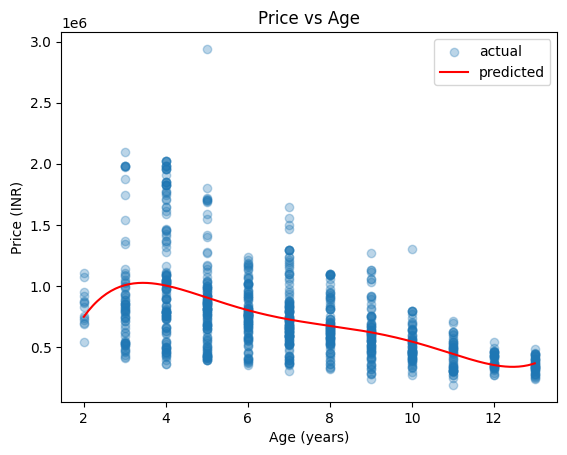

In [34]:
best_deg = 5
X_best = np.column_stack([df3['Age'].values**i for i in range(1, best_deg+1)])
X_best = sm.add_constant(X_best)
m_best = sm.OLS(df3['Price'], X_best).fit()

age_range = np.linspace(df3['Age'].min(), df3['Age'].max(), 200)
X_pred = sm.add_constant(np.column_stack([age_range**i for i in range(1, best_deg+1)]))
preds = m_best.predict(X_pred)

plt.scatter(df3['Age'], df3['Price'], alpha=0.3, label='actual')
plt.plot(age_range, preds, color='red', label='predicted')
plt.xlabel('Age (years)')
plt.ylabel('Price (INR)')
plt.title('Price vs Age')
plt.legend()
plt.show()
# model captures the general downward trend but struggles with spread at lower ages

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [35]:
df4 = pd.read_csv('./data/heart_hw.csv')
df4['treated'] = (df4['transplant'] == 'treatment').astype(int)
df4.head()

,Unnamed: 0,age,transplant,y,treated
0,1,53,control,0,0
1,2,43,control,0,0
2,3,52,control,0,0
3,4,52,control,0,0
4,5,54,control,0,0


In [36]:
control_surv = df4[df4['transplant'] == 'control']['y'].mean()
treat_surv = df4[df4['transplant'] == 'treatment']['y'].mean()
ate = treat_surv - control_surv

print(f'control survival rate: {control_surv:.4f}')
print(f'treatment survival rate: {treat_surv:.4f}')
print(f'ATE: {ate:.4f}')
# ATE = 0.23, transplant recipients survive at a higher rate

control survival rate: 0.1176
treatment survival rate: 0.3478
ATE: 0.2302


In [37]:
X2 = sm.add_constant(df4['treated'])
m2 = sm.OLS(df4['y'], X2).fit()
print(m2.summary())
# intercept = control survival rate (0.1176)
# treated coef = ATE (0.2302), exactly matches what we computed above

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0133
Time:                        23:49:59   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1176      0.075      1.574      0.1

In [38]:
X3 = sm.add_constant(pd.concat([df4['treated'], df4['age']], axis=1))
m3 = sm.OLS(df4['y'], X3).fit()
print(m3.summary())
# transplant coef goes up slightly to 0.265 when controlling for age
# intercept is predicted survival at age 0 (not meaningful on its own)
# age slope is negative - older patients are less likely to survive

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000357
Time:                        23:50:01   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7020      0.196      3.583      0.0

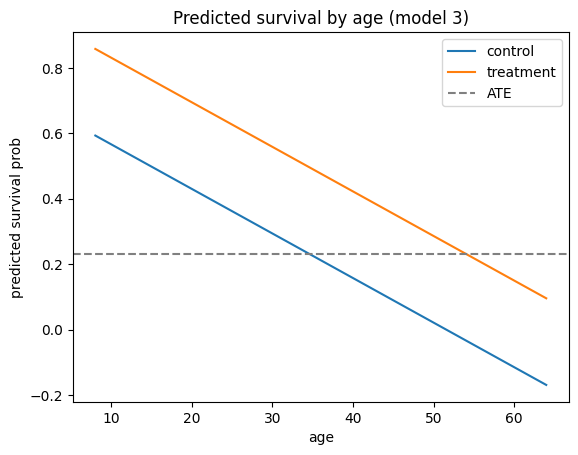

In [40]:
age_range = np.linspace(df4['age'].min(), df4['age'].max(), 100)

for label, val in [('control', 0), ('treatment', 1)]:
    X_plot = np.column_stack([
        np.ones(100),
        np.full(100, val),
        age_range
    ])
    preds = m3.predict(X_plot)
    plt.plot(age_range, preds, label=label)

plt.axhline(ate, linestyle='--', color='gray', label='ATE')
plt.xlabel('age')
plt.ylabel('predicted survival prob')
plt.title('Predicted survival by age (model 3)')
plt.legend()
plt.show()
# ATE overestimates impact for older patients, underestimates for younger ones

In [41]:
df4['treat_age'] = df4['treated'] * df4['age']
X4 = sm.add_constant(pd.concat([df4['treated'], df4['age'], df4['treat_age']], axis=1))
m4 = sm.OLS(df4['y'], X4).fit()
print(m4.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000310
Time:                        23:57:14   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3549      0.280      1.269      0.2

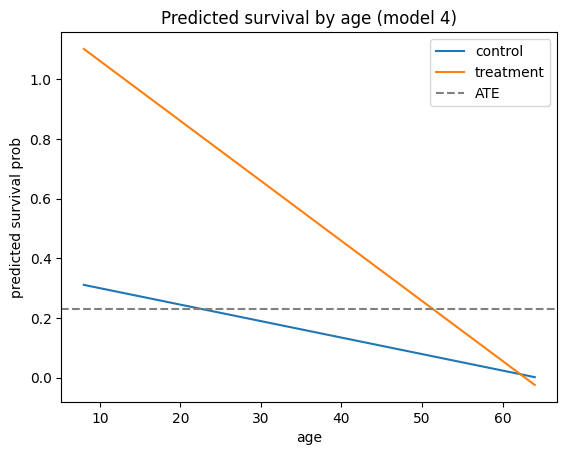

In [43]:
for label, val in [('control', 0), ('treatment', 1)]:
    X_plot = np.column_stack([
        np.ones(100),
        np.full(100, val),
        age_range,
        val * age_range
    ])
    preds = m4.predict(X_plot)
    plt.plot(age_range, preds, label=label)

plt.axhline(ate, linestyle='--', color='gray', label='ATE')
plt.xlabel('age')
plt.ylabel('predicted survival prob')
plt.title('Predicted survival by age (model 4)')
plt.legend()
plt.show()
# the treatment benefit shrinks with age - younger patients gain more from transplant

In [44]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
y = df4['y'].values

models = {
    'model 2 (transplant only)': sm.add_constant(df4['treated']).values,
    'model 3 (+ age)': sm.add_constant(pd.concat([df4['treated'], df4['age']], axis=1)).values,
    'model 4 (+ interaction)': sm.add_constant(pd.concat([df4['treated'], df4['age'], df4['treat_age']], axis=1)).values
}

for name, X in models.items():
    scores = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='neg_root_mean_squared_error')
    print(f'{name}: RMSE = {-scores.mean():.4f}')

# model 4 has lowest RMSE but the improvement is small

model 2 (transplant only): RMSE = 0.4365
model 3 (+ age): RMSE = 0.4167
model 4 (+ interaction): RMSE = 0.4130


Some concerns:

- The dataset is very small (103 patients), so estimates are noisy and may not generalize
- The model is a linear probability model, so predicted probabilities can fall outside [0,1]
- There may be confounding - treatment group patients likely differ from control in ways we're not measuring